In [14]:
import pandas as pd
from pathlib import Path
import re


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [18]:

from sentence_transformers import SentenceTransformer
import umap
import hdbscan

In [67]:
radar_topics = pd.read_csv(Path('/data/elugos/radar_topic/vehiclela_radar_topics.csv'))

In [68]:
d_texts = pd.read_csv(Path('/data/elugos/radar_topic/vehiclela_d_texts.csv'))

In [69]:
d_texts = d_texts.rename(columns= {"0":'texts'})

In [70]:
radar_topic_0 = radar_topics[radar_topics["Topic"] == 0]

In [71]:
d_texts

,texts,date
0,abohar native sunil yadav shoot dead californi...,2024-12-24
1,southern california police department give gif...,2024-12-24
2,man accuse kill year old son significant menta...,2024-12-24
3,asheville police near end helene recovery pers...,2024-12-24
4,police shoot victim pete hodge idolize cop law...,2024-12-24
...,...,...
505,miss salinas nurse abandon vehicle locate mile...,2025-02-01
506,man officer shoot kill orange county pier alle...,2025-02-01
507,attack police jb pritzker flames trump hurt la...,2025-02-01
508,soldier kill fort stewart vehicle incident nig...,2025-02-01


In [72]:
df = d_texts.merge(
    radar_topics,
    left_on="texts",
    right_on="Document",
    how="inner"
)


In [73]:
df

,texts,date,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,abohar native sunil yadav shoot dead californi...,2024-12-24,abohar native sunil yadav shoot dead californi...,-1,-1_police_attack_court_new,"['police', 'attack', 'court', 'new', 'californ...",['new year new law california employer. slew n...,police - attack - court - new - california - s...,0.343200,False
1,southern california police department give gif...,2024-12-24,southern california police department give gif...,-1,-1_police_attack_court_new,"['police', 'attack', 'court', 'new', 'californ...",['new year new law california employer. slew n...,police - attack - court - new - california - s...,0.371452,False
2,man accuse kill year old son significant menta...,2024-12-24,man accuse kill year old son significant menta...,0,0_shoot_kill_border_patrol,"['shoot', 'kill', 'border', 'patrol', 'man', '...",['woman arrest charge minnesota native border ...,shoot - kill - border - patrol - man - border ...,0.598297,False
3,asheville police near end helene recovery pers...,2024-12-24,asheville police near end helene recovery pers...,-1,-1_police_attack_court_new,"['police', 'attack', 'court', 'new', 'californ...",['new year new law california employer. slew n...,police - attack - court - new - california - s...,0.273478,False
4,police shoot victim pete hodge idolize cop law...,2024-12-24,police shoot victim pete hodge idolize cop law...,0,0_shoot_kill_border_patrol,"['shoot', 'kill', 'border', 'patrol', 'man', '...",['woman arrest charge minnesota native border ...,shoot - kill - border - patrol - man - border ...,1.000000,False
...,...,...,...,...,...,...,...,...,...,...
505,miss salinas nurse abandon vehicle locate mile...,2025-02-01,miss salinas nurse abandon vehicle locate mile...,-1,-1_police_attack_court_new,"['police', 'attack', 'court', 'new', 'californ...",['new year new law california employer. slew n...,police - attack - court - new - california - s...,0.311295,False
506,man officer shoot kill orange county pier alle...,2025-02-01,man officer shoot kill orange county pier alle...,0,0_shoot_kill_border_patrol,"['shoot', 'kill', 'border', 'patrol', 'man', '...",['woman arrest charge minnesota native border ...,shoot - kill - border - patrol - man - border ...,1.000000,False
507,attack police jb pritzker flames trump hurt la...,2025-02-01,attack police jb pritzker flames trump hurt la...,2,2_trump_vehicle_russia_say,"['trump', 'vehicle', 'russia', 'say', 'preside...",['russia ukraine sanction update month decembe...,trump - vehicle - russia - say - president - y...,1.000000,False
508,soldier kill fort stewart vehicle incident nig...,2025-02-01,soldier kill fort stewart vehicle incident nig...,0,0_shoot_kill_border_patrol,"['shoot', 'kill', 'border', 'patrol', 'man', '...",['woman arrest charge minnesota native border ...,shoot - kill - border - patrol - man - border ...,0.340859,False


In [74]:


def radar_top_words_freq(df, topic_id: int, top_k: int = 10,
                         doc_col: str = "Document", word_col: str = "Top_n_words",
                         normalize: bool = True):
    sub = df[df["Topic"] == topic_id]
    if sub.empty:
        raise ValueError(f"Topic {topic_id} not found")

    top_words_str = sub.iloc[0][word_col]
    words = [w.strip() for w in str(top_words_str).split(" - ") if w.strip()]
    words = words[:top_k]

    # Build frequency across all docs in this topic
    docs = sub[doc_col].fillna("").astype(str).tolist()
    freqs = []
    for w in words:
        # word-boundary match; handles multiword phrases too
        pattern = r"\b" + re.escape(w.lower()) + r"\b"
        count = sum(len(re.findall(pattern, d.lower())) for d in docs)
        freqs.append(count)

    values = np.array(freqs, dtype=float)

    # Normalize within topic so max word = 1.0
    if normalize:
        mx = values.max()
        values = values / mx if mx > 0 else values

    # Close loop
    values = np.append(values, values[0])
    angles = np.linspace(0, 2*np.pi, len(words), endpoint=False)
    angles = np.append(angles, angles[0])

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(angles[:-1] * 180 / np.pi, words)

    title_suffix = "freq (normalized)" if normalize else "freq (raw)"
    ax.set_title(f"Topic {topic_id} — Top {top_k} words by {title_suffix}", y=1.1)

    if normalize:
        ax.set_ylim(0, 1.05)
    else:
        ax.set_ylim(0, values.max() * 1.05 if values.max() > 0 else 1)

    plt.show()

# Example:



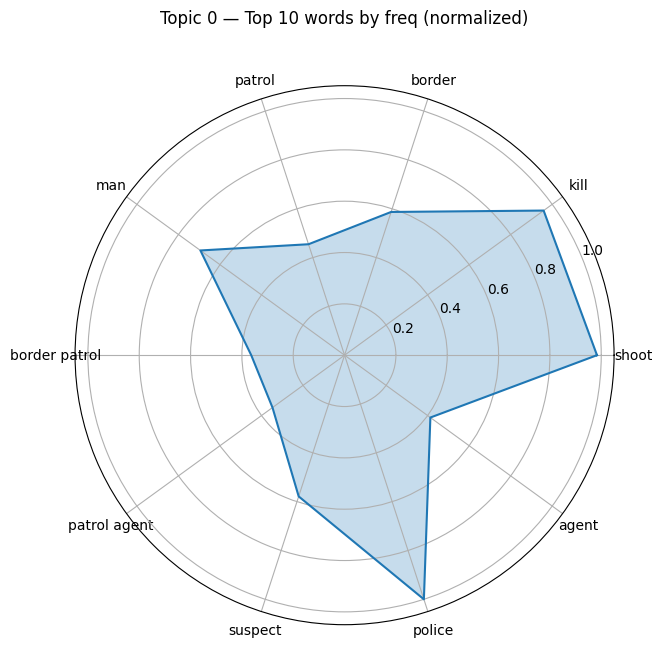

In [75]:
radar_top_words_freq(radar_topics, topic_id=0, top_k=10, normalize=True)

In [76]:
def radar_top_words_freq_by_date(
    df,
    topic_id: int,
    date_col: str = "date",          # <-- change to your actual date column name
    top_k: int = 10,
    doc_col: str = "Document",
    word_col: str = "Top_n_words",
    normalize: bool = True,
    dropna_dates: bool = True,
):
    dfx = df.copy()

    # Ensure date column is datetime (works if it's already datetime too)
    dfx[date_col] = np.where(
        dfx[date_col].isna(),
        dfx[date_col],
        dfx[date_col]
    )
    dfx[date_col] = pd.to_datetime(dfx[date_col], errors="coerce")

    if dropna_dates:
        dfx = dfx.dropna(subset=[date_col])

    # Loop dates in sorted order
    for dt in sorted(dfx[date_col].dt.date.unique()):
        sub_date = dfx[dfx[date_col].dt.date == dt]
        sub = sub_date[sub_date["Topic"] == topic_id]

        if sub.empty:
            continue  # no docs for this topic on this date

        # Get topic top words (string repeated; take first)
        top_words_str = sub.iloc[0][word_col]
        words = [w.strip() for w in str(top_words_str).split(" - ") if w.strip()][:top_k]

        # Frequency across docs in this topic+date slice
        docs = sub[doc_col].fillna("").astype(str).tolist()
        freqs = []
        for w in words:
            pattern = r"\b" + re.escape(w.lower()) + r"\b"
            count = sum(len(re.findall(pattern, d.lower())) for d in docs)
            freqs.append(count)

        values = np.array(freqs, dtype=float)

        if normalize:
            mx = values.max()
            values = values / mx if mx > 0 else values

        # Close loop
        values_plot = np.append(values, values[0])
        angles = np.linspace(0, 2*np.pi, len(words), endpoint=False)
        angles = np.append(angles, angles[0])

        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
        ax.plot(angles, values_plot)
        ax.fill(angles, values_plot, alpha=0.25)
        ax.set_thetagrids(angles[:-1] * 180 / np.pi, words)

        title_suffix = "freq (normalized)" if normalize else "freq (raw)"
        ax.set_title(f"Topic {topic_id} — {dt} — Top {top_k} words by {title_suffix}", y=1.1)

        if normalize:
            ax.set_ylim(0, 1.05)
        else:
            ax.set_ylim(0, values.max() * 1.05 if values.max() > 0 else 1)

        plt.show()

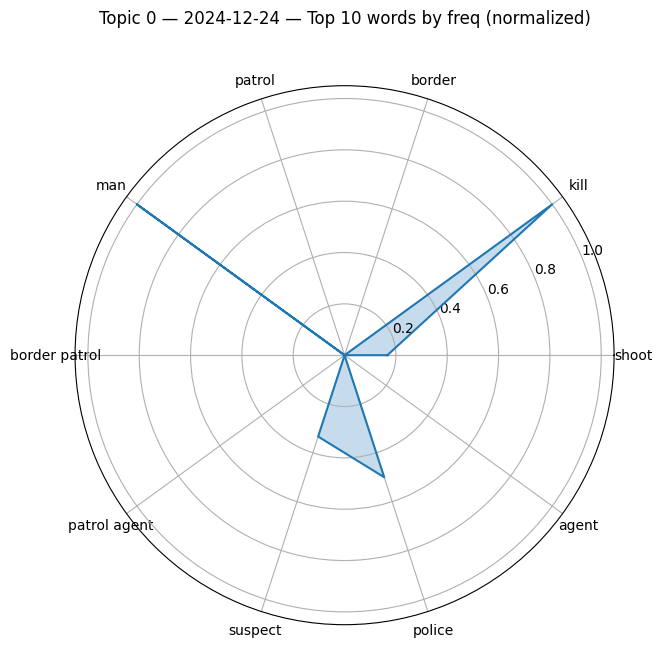

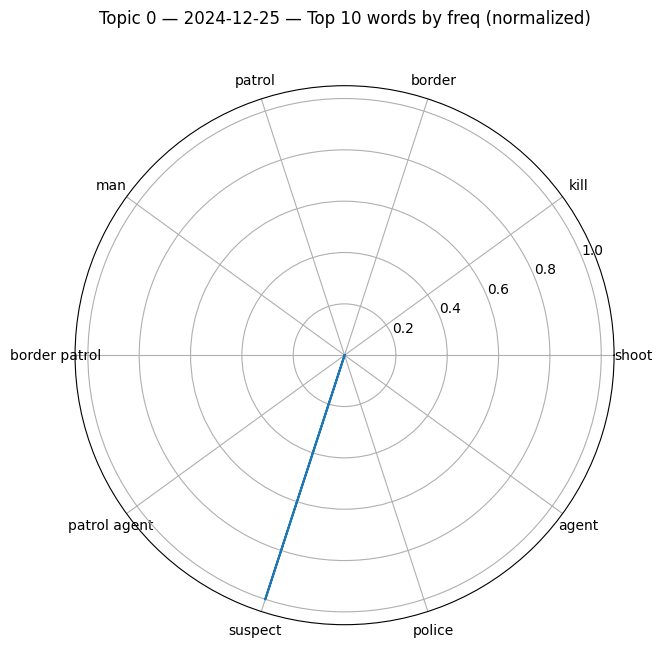

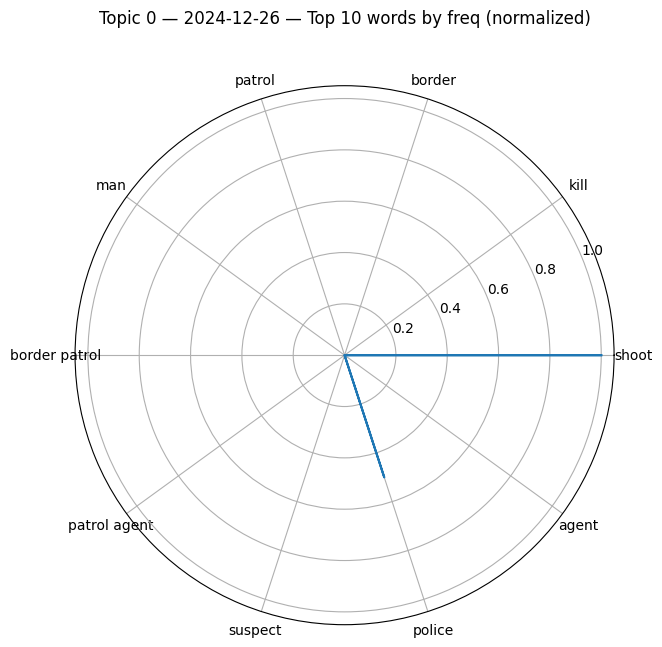

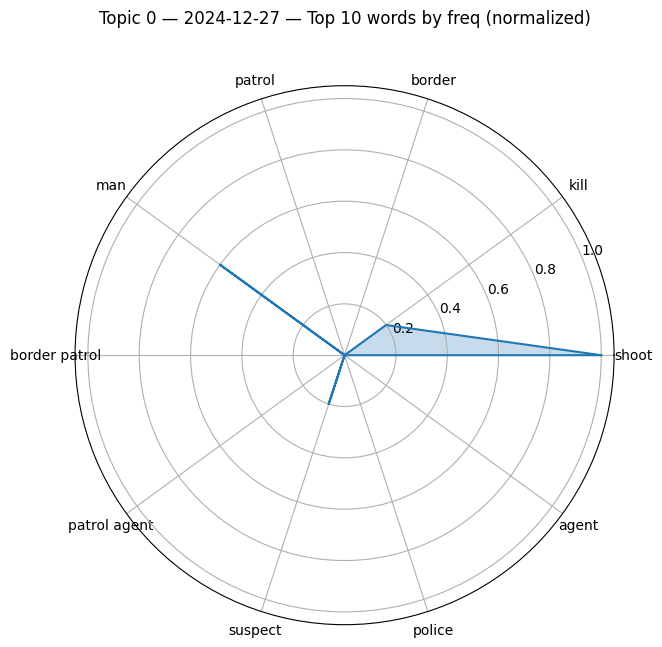

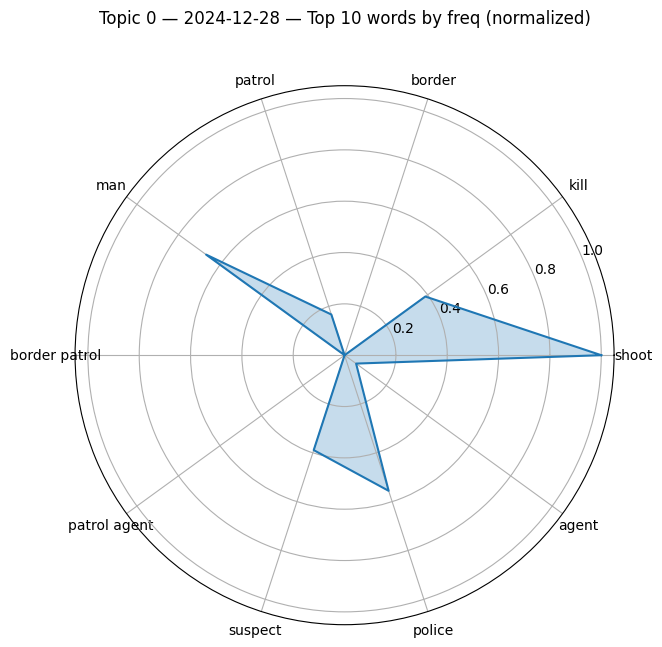

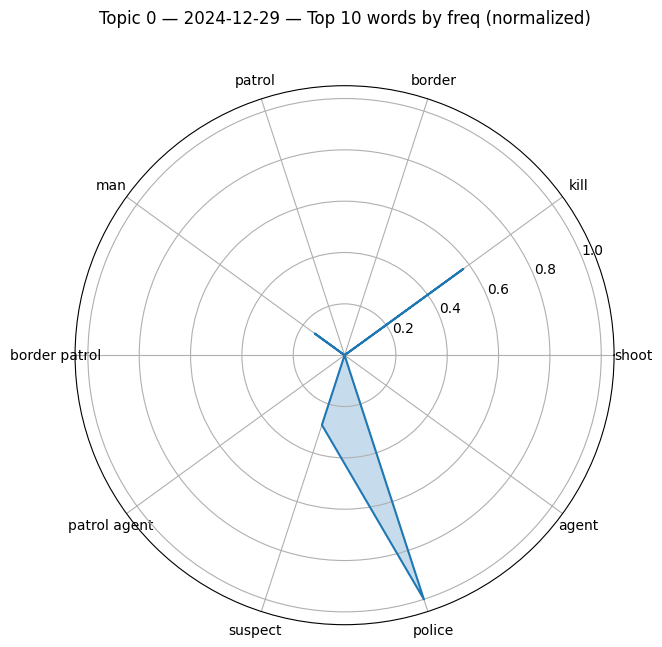

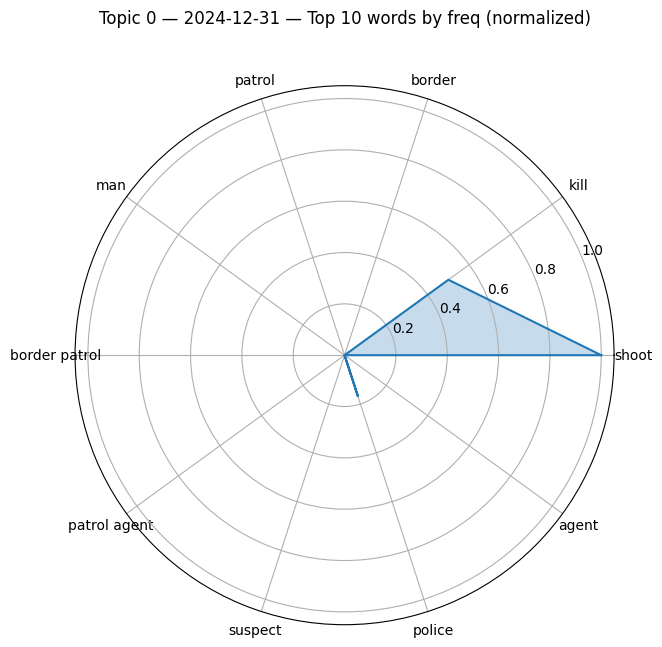

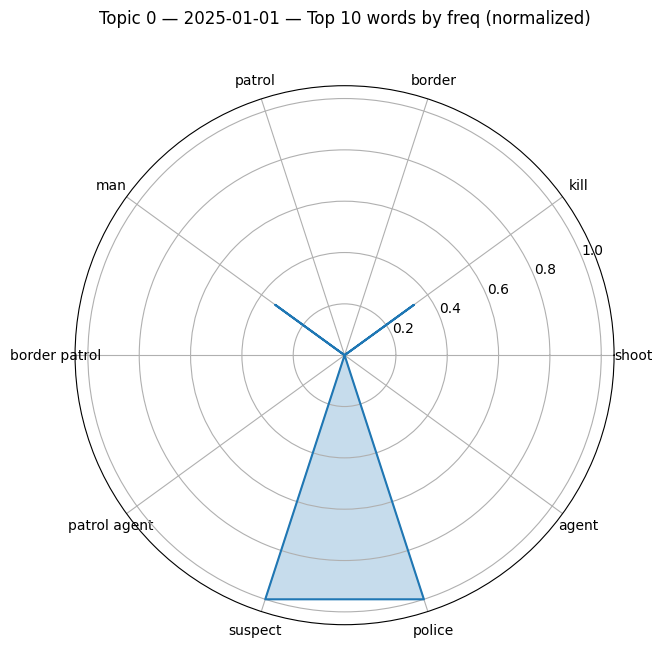

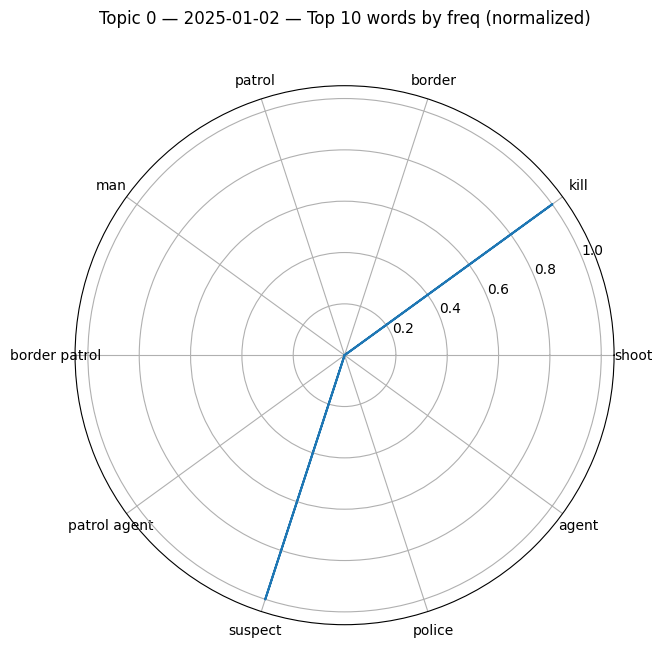

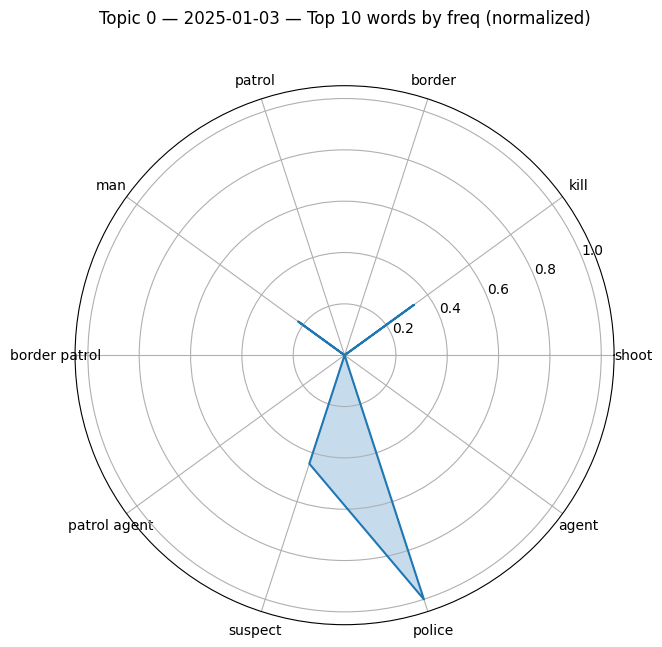

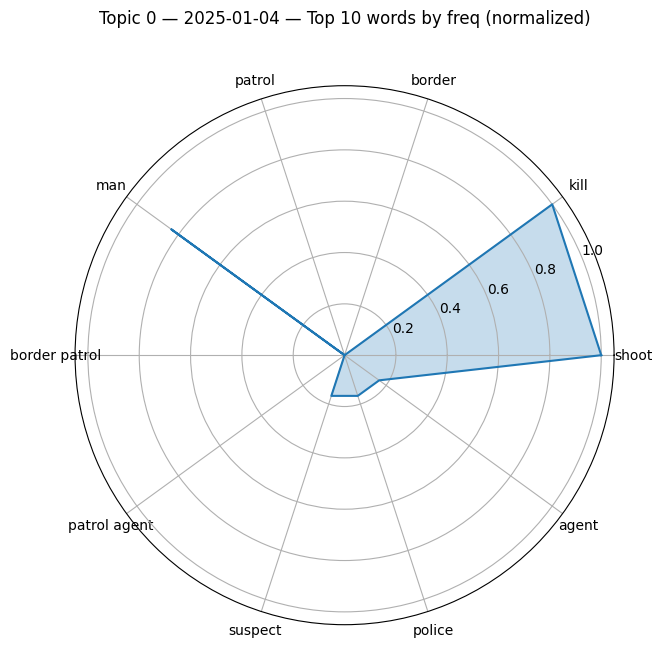

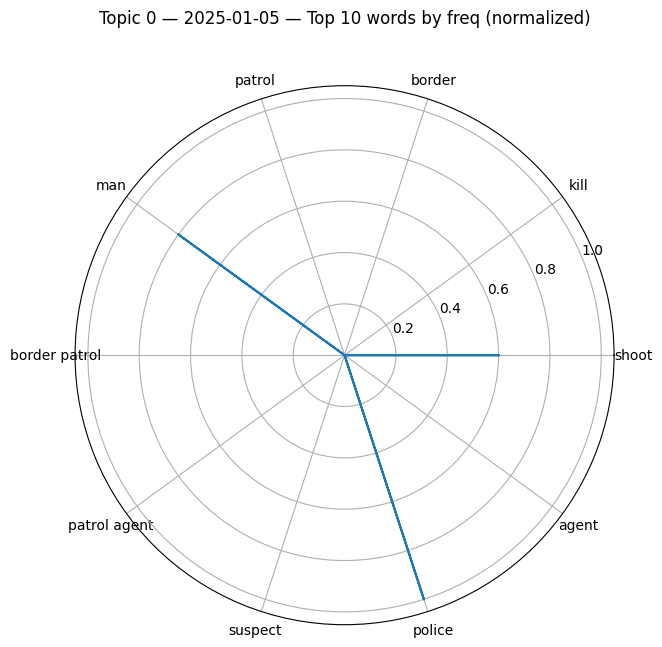

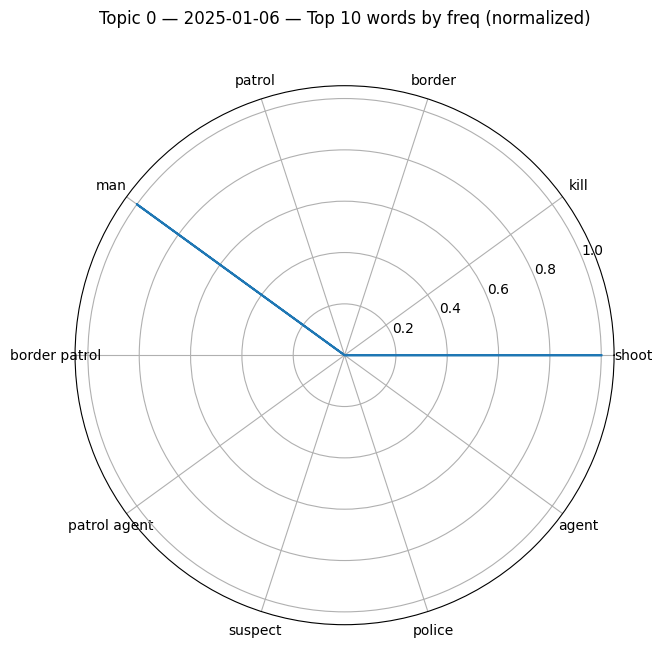

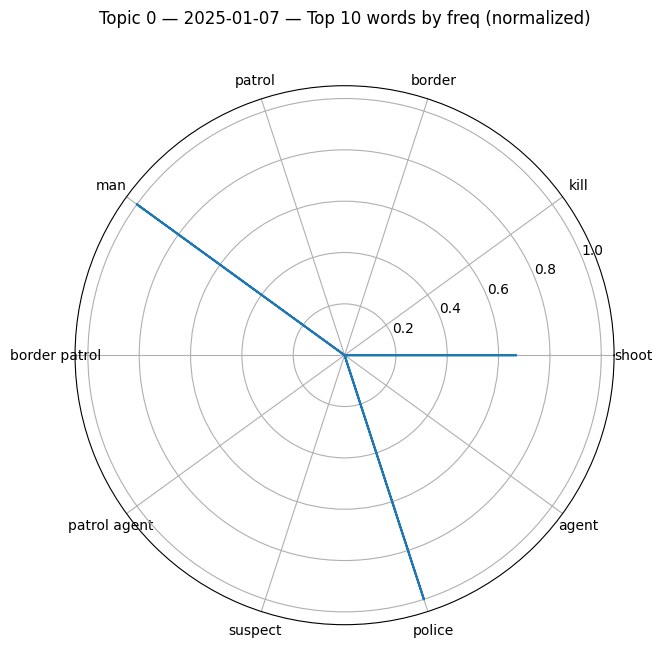

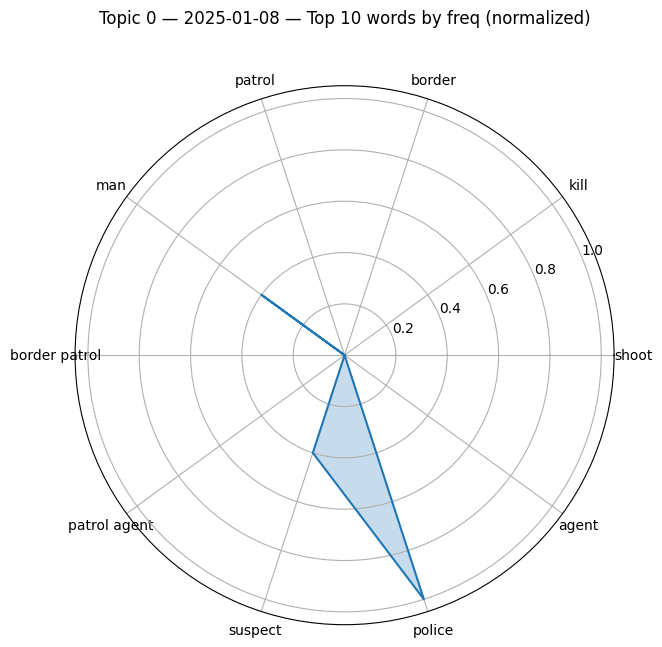

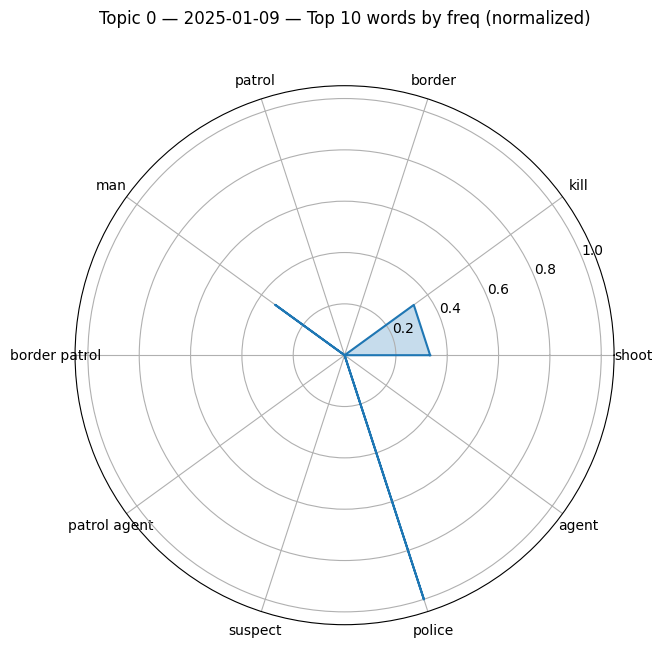

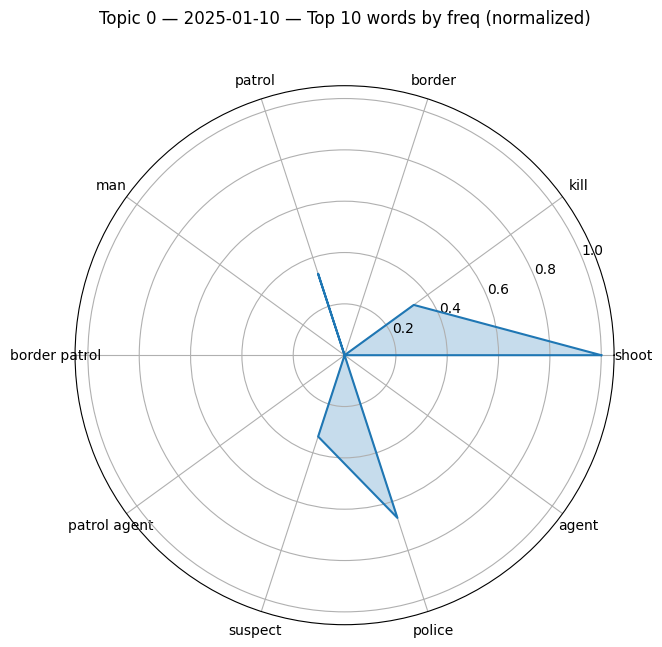

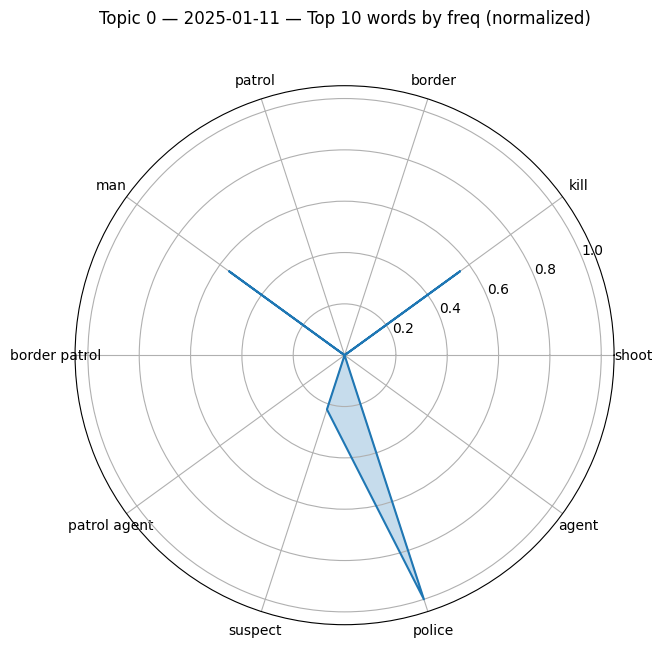

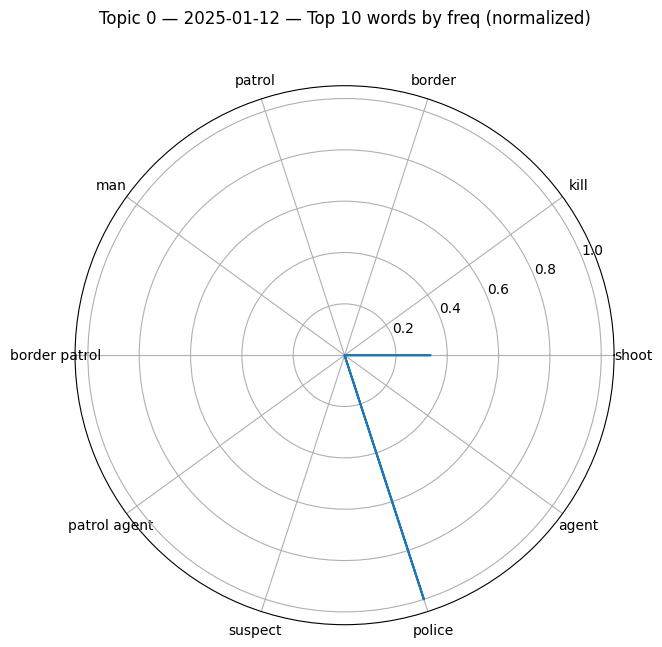

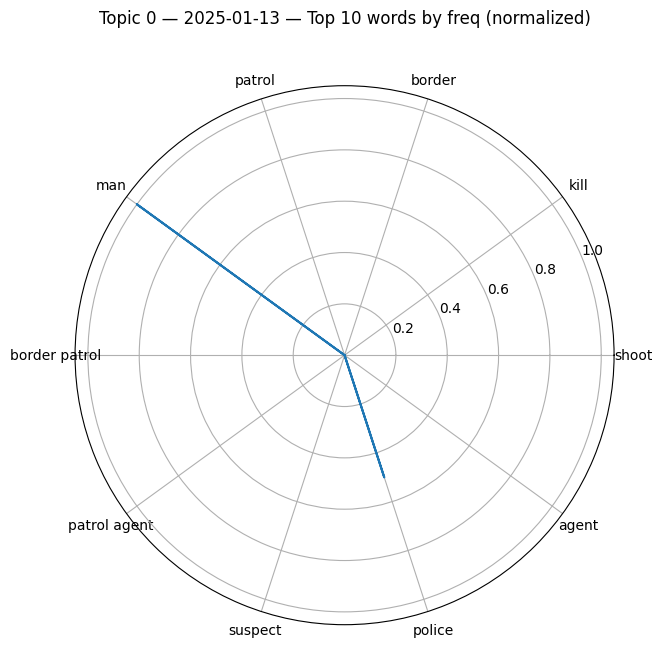

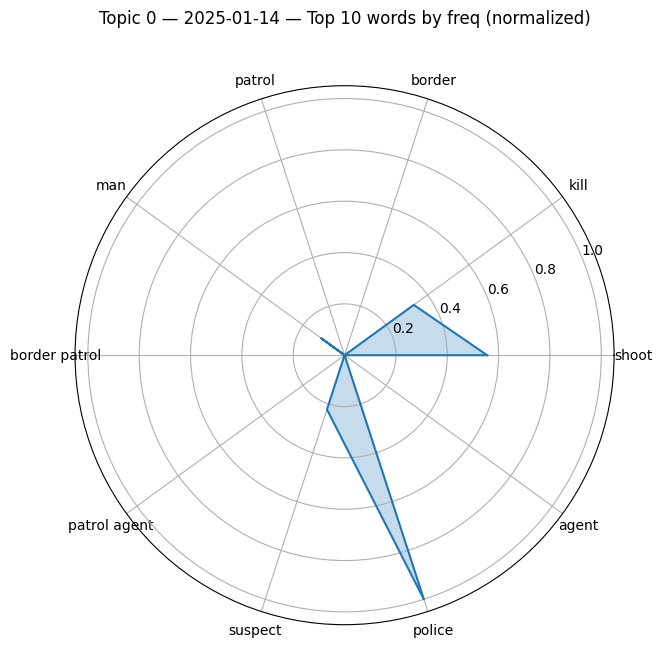

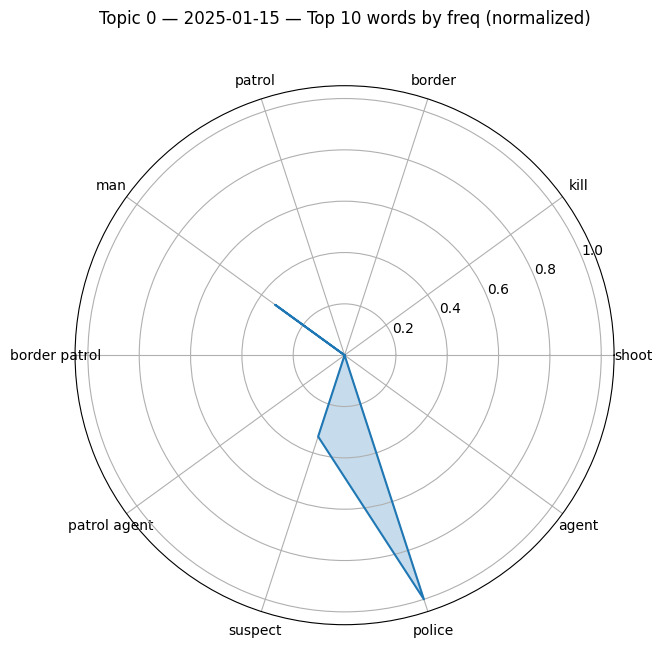

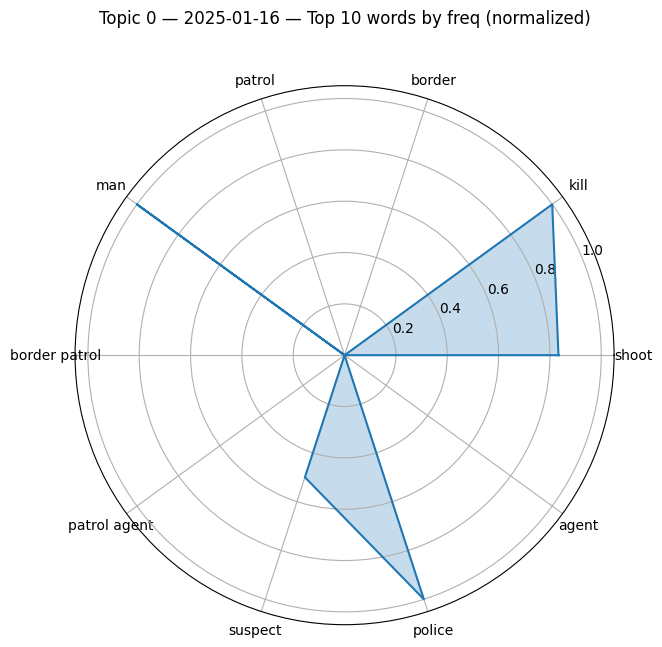

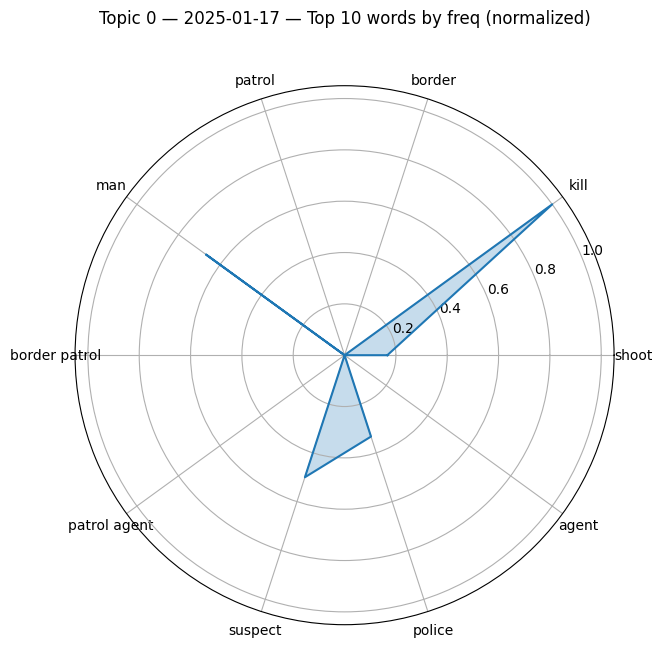

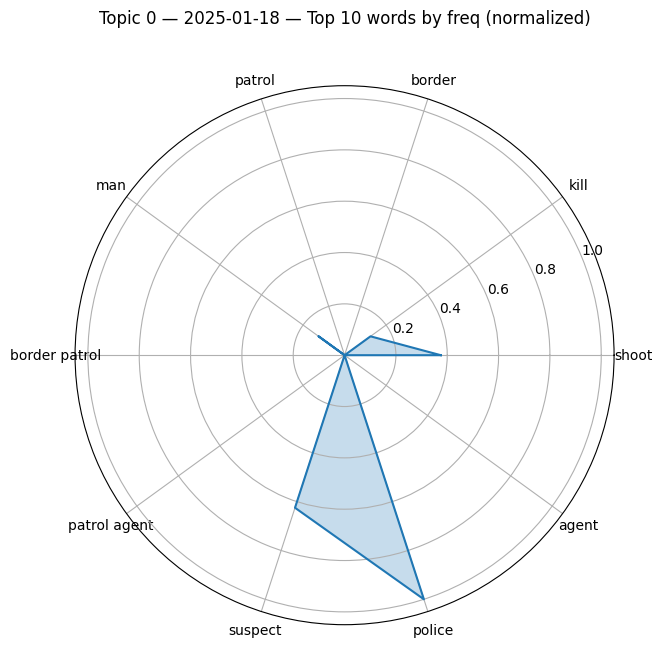

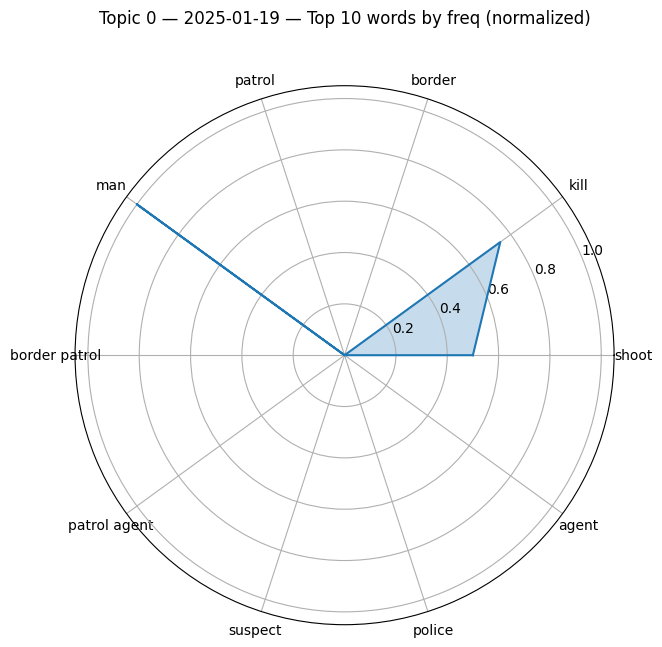

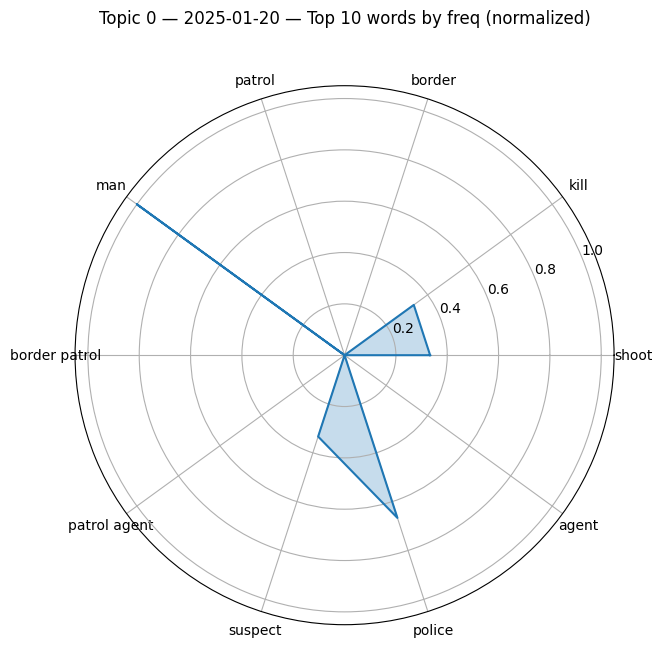

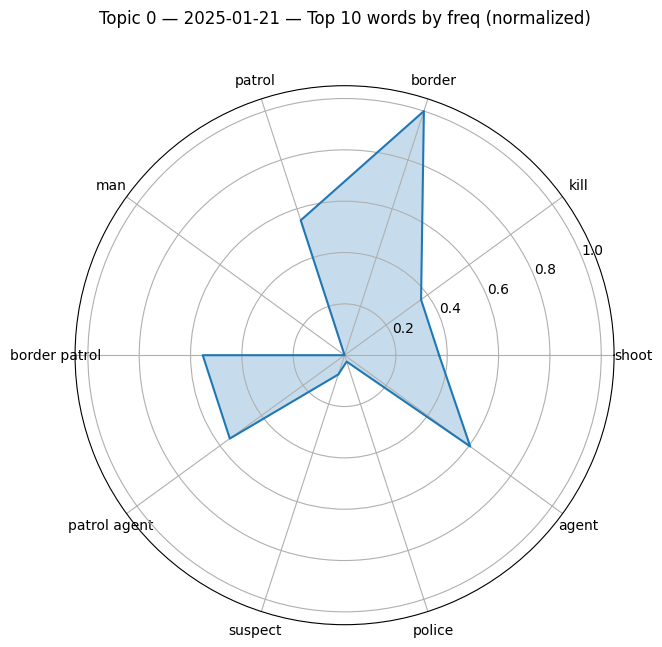

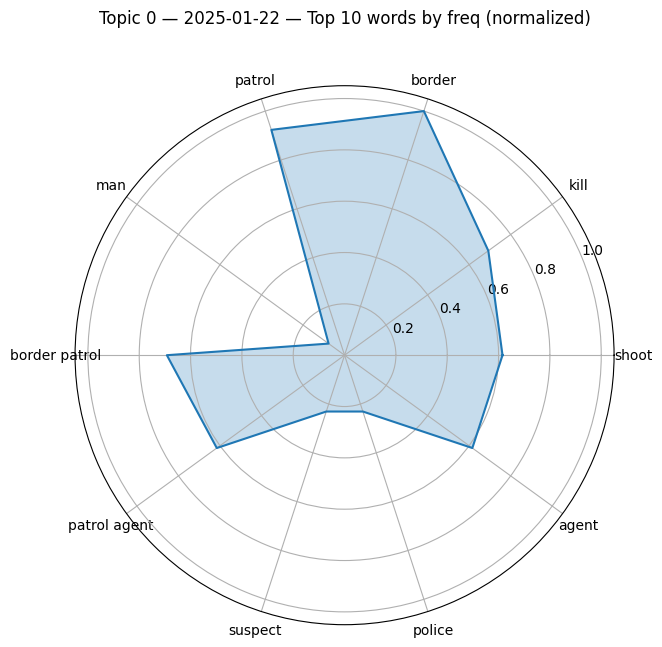

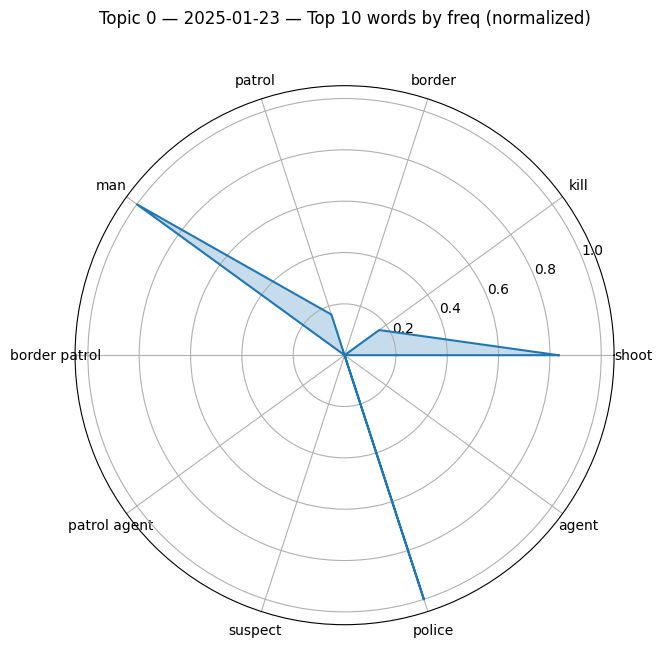

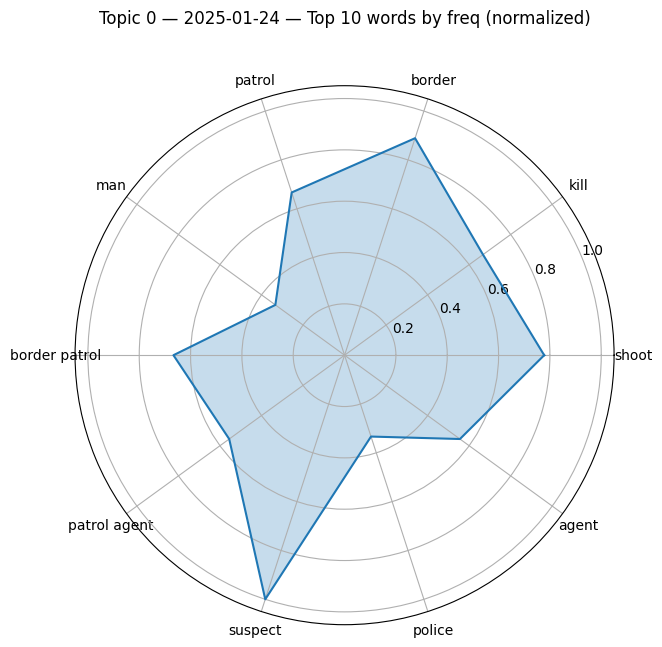

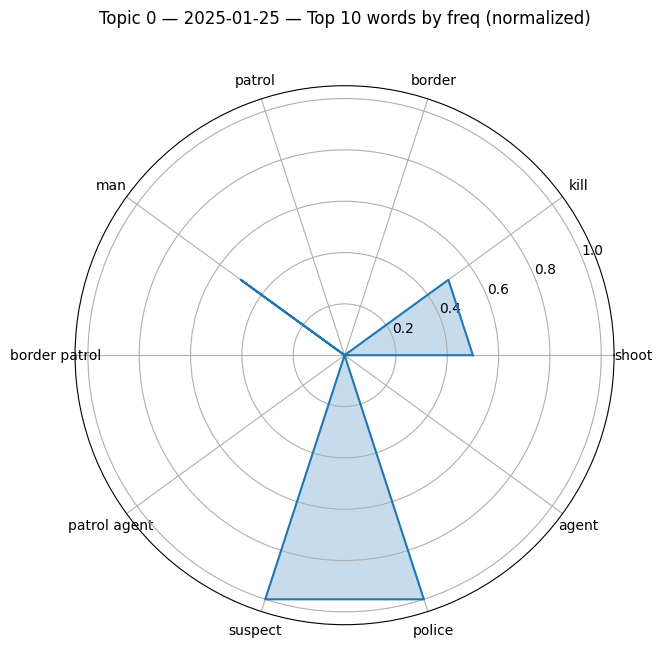

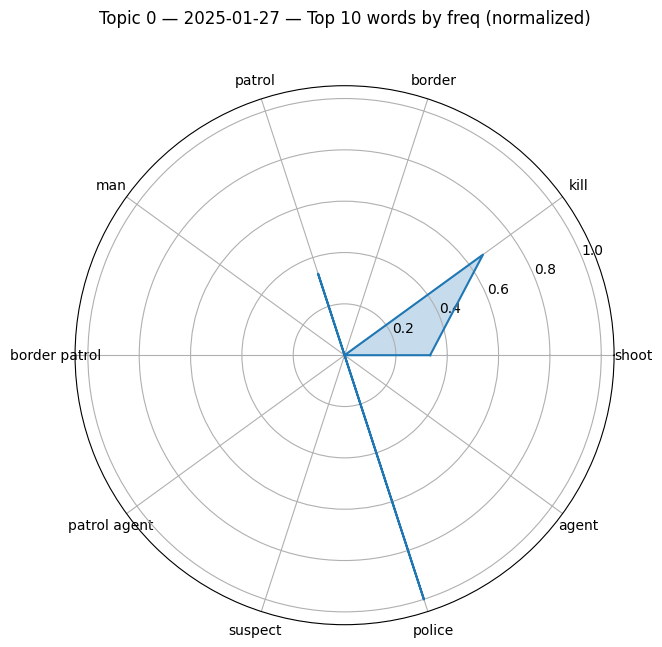

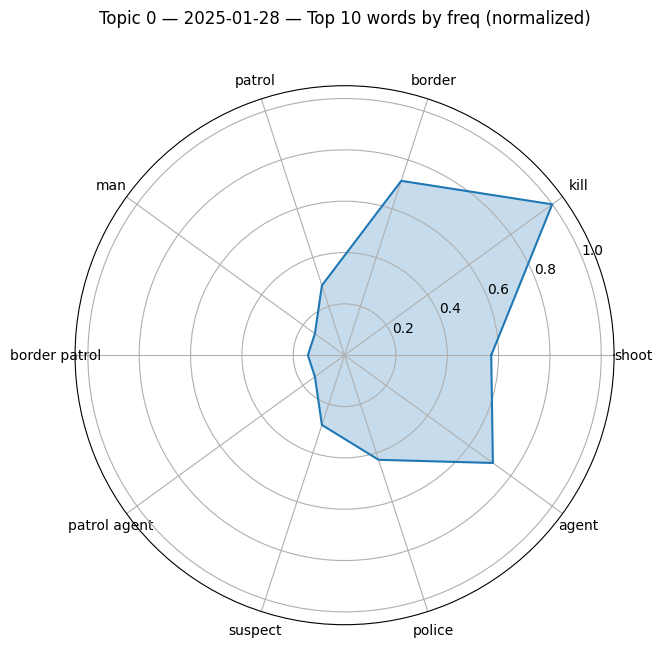

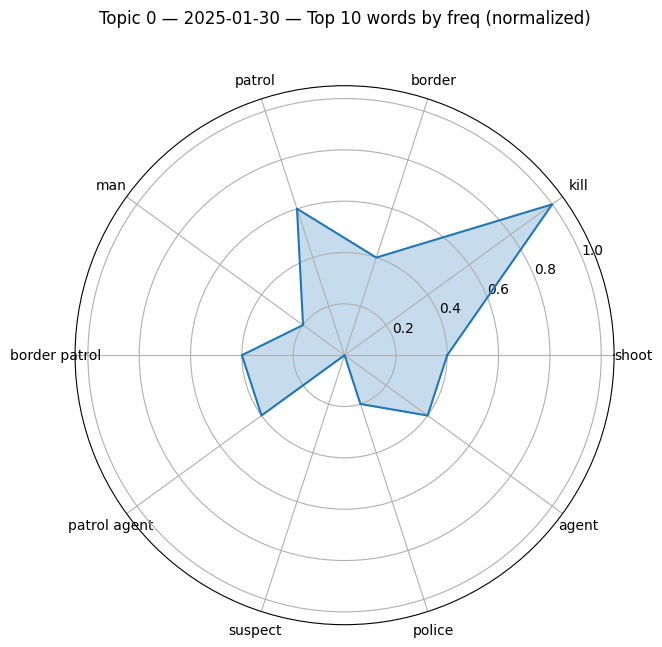

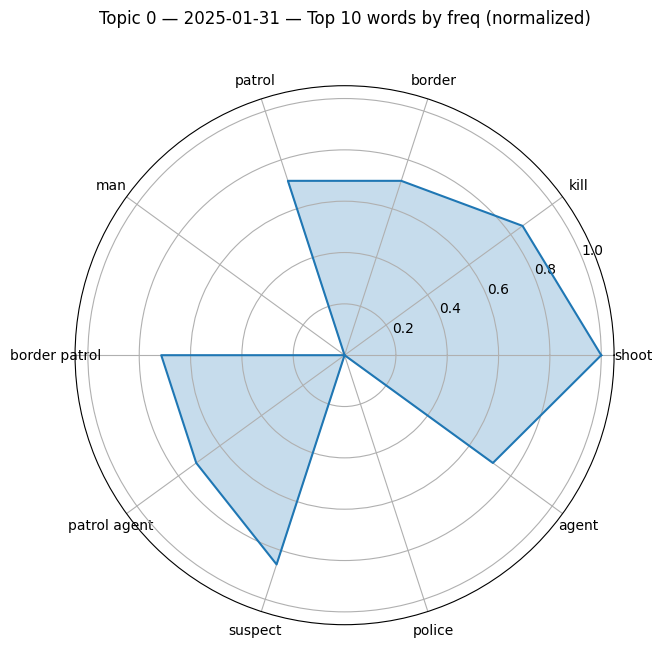

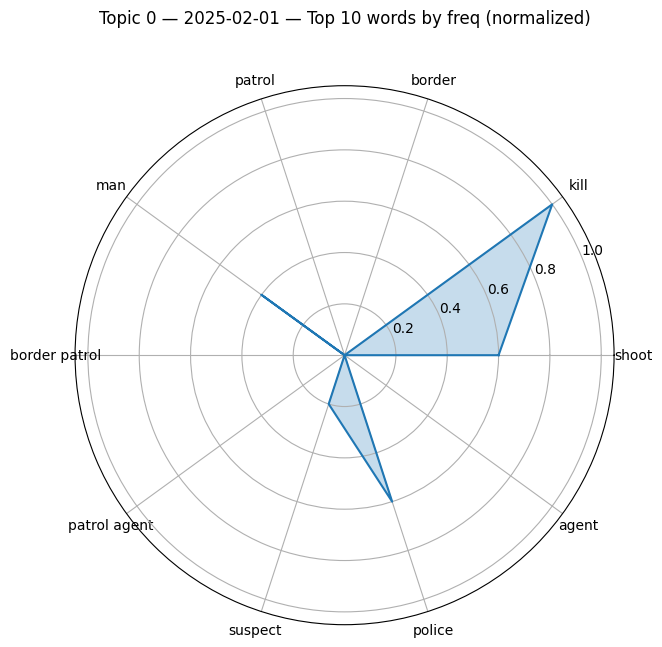

In [77]:
radar_top_words_freq_by_date(
    df=df,
    topic_id=0,
    date_col="date",   # <-- replace with your actual date col name
    top_k=10,
    normalize=True
)

In [78]:

def radar_top_words_freq_by_week(
    df,
    topic_id: int,
    date_col: str = "date",      # <-- set this to your actual date column
    top_k: int = 10,
    doc_col: str = "Document",
    word_col: str = "Top_n_words",
    normalize: bool = True,
    week_freq: str = "W-MON", 
    topic: str = 'test',   # weeks start Monday
):
    dfx = df.copy()

    # Ensure datetime
    dfx[date_col] = pd.to_datetime(dfx[date_col], errors="coerce")
    dfx = dfx.dropna(subset=[date_col])

    # Create week column
    dfx["week"] = dfx[date_col].dt.to_period(week_freq)

    # Loop over weeks in order
    for week in sorted(dfx["week"].unique()):
        sub_week = dfx[dfx["week"] == week]
        sub = sub_week[sub_week["Topic"] == topic_id]

        if sub.empty:
            continue  # no docs for this topic this week

        # Top words string (same for topic; take first)
        top_words_str = sub.iloc[0][word_col]
        words = [w.strip() for w in str(top_words_str).split(" - ") if w.strip()]
        words = words[:top_k]

        # Frequency across docs in this topic-week
        docs = sub[doc_col].fillna("").astype(str).tolist()
        freqs = []
        for w in words:
            pattern = r"\b" + re.escape(w.lower()) + r"\b"
            count = sum(len(re.findall(pattern, d.lower())) for d in docs)
            freqs.append(count)

        values = np.array(freqs, dtype=float)

        if normalize:
            mx = values.max()
            values = values / mx if mx > 0 else values

        # Close radar loop
        values_plot = np.append(values, values[0])
        angles = np.linspace(0, 2*np.pi, len(words), endpoint=False)
        angles = np.append(angles, angles[0])

        # Plot
        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
        ax.plot(angles, values_plot)
        ax.fill(angles, values_plot, alpha=0.25)
        ax.set_thetagrids(angles[:-1] * 180 / np.pi, words)

        title_suffix = "freq (normalized)" if normalize else "freq (raw)"
        ax.set_title(
            f"Topic {topic_id} — Week {week.start_time.date()} → {week.end_time.date()} — {title_suffix}",
            y=1.1
        )

        if normalize:
            ax.set_ylim(0, 1.05)
        else:
            ax.set_ylim(0, values.max() * 1.05 if values.max() > 0 else 1)
            
    week_label = f"{week.start_time.date()}_{week.end_time.date()}"
    fname = f"elpaso_{topic_id}_week_{week_label}.png"

    plt.savefig(fname, dpi=200, bbox_inches="tight")        

    plt.show()
    plt.close()

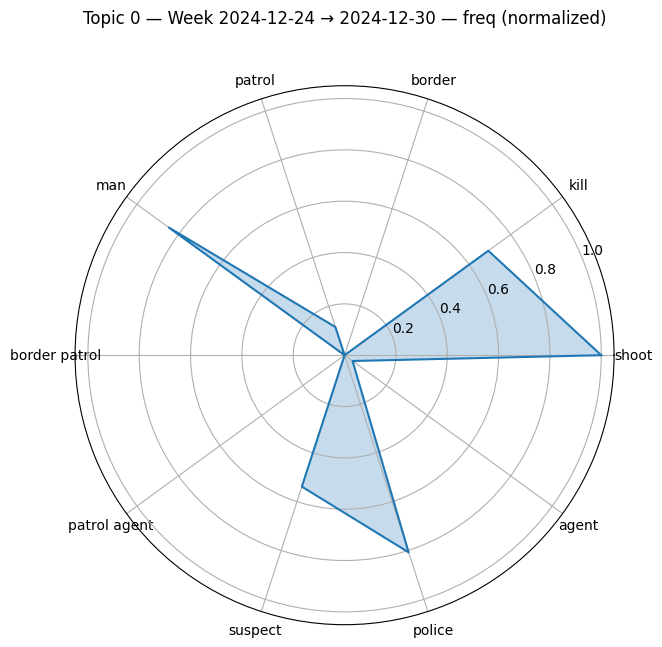

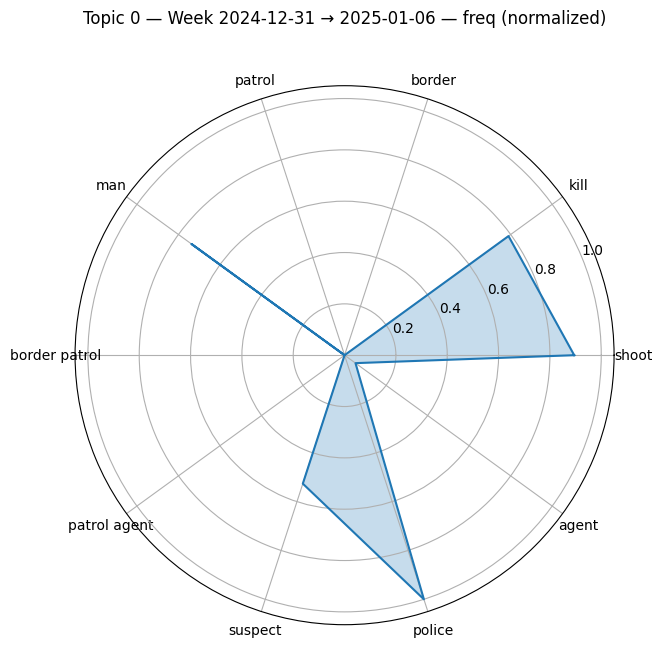

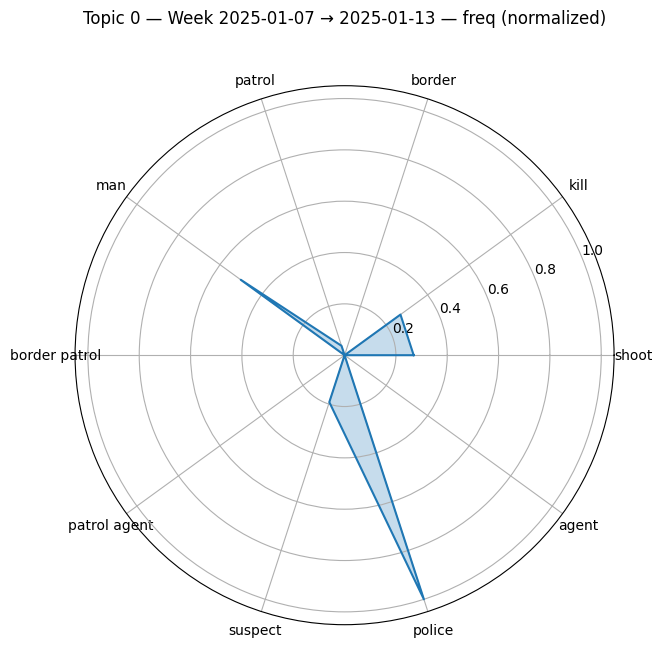

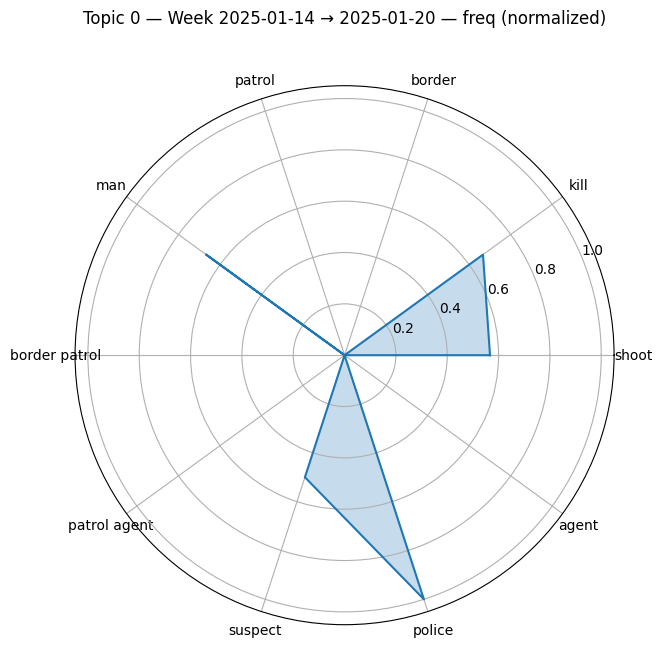

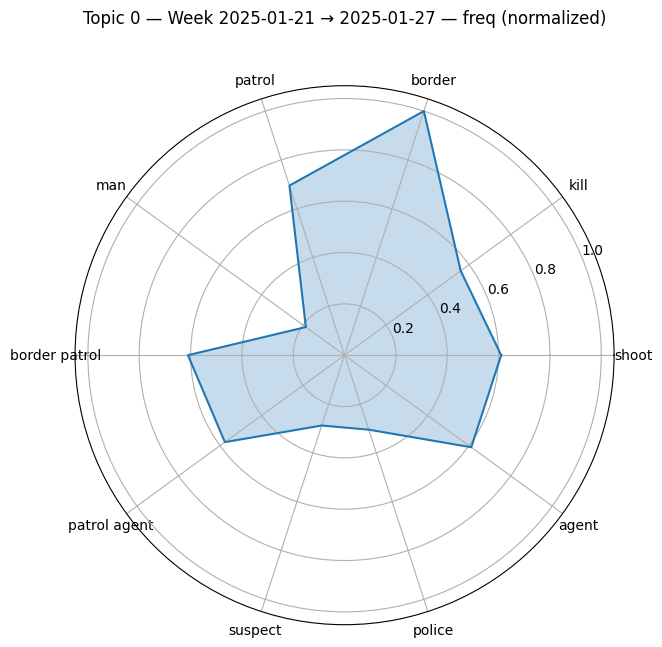

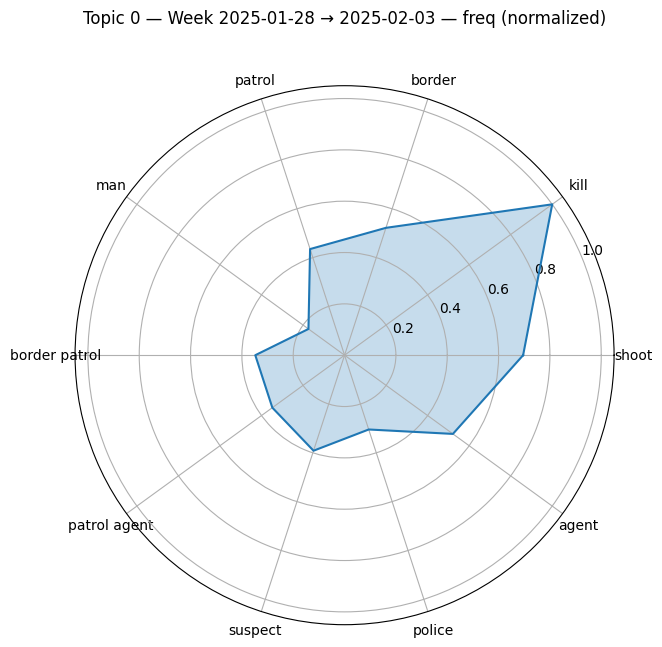

In [79]:
radar_top_words_freq_by_week(
    df=df,
    topic_id=0,
    date_col="date",   # <-- change if needed
    top_k=10,
    normalize=True,
    topic = 'elpaso'
)


In [25]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")
from sklearn.feature_extraction.text import TfidfVectorizer



In [20]:
df = radar_topics.copy()

In [21]:
def cluster_and_plot_topic(
    df,
    topic_id: int,
    text_col: str = "Document",
    min_cluster_size: int = 5
):
    sub = df[df["Topic"] == topic_id]

    if len(sub) < min_cluster_size:
        print(f"Skipping Topic {topic_id} (too few docs)")
        return

    docs = sub[text_col].fillna("").astype(str).tolist()

    # ---- Embed ----
    embeddings = embedder.encode(docs, show_progress_bar=False)

    # ---- Cluster ----
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean"
    )
    labels = clusterer.fit_predict(embeddings)

    # ---- Reduce to 2D ----
    reducer = umap.UMAP(
        n_neighbors=10,
        min_dist=0.1,
        metric="cosine",
        random_state=42
    )
    coords = reducer.fit_transform(embeddings)

    # ---- Plot ----
    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        coords[:, 0],
        coords[:, 1],
        c=labels,
        cmap="tab10",
        s=20,
        alpha=0.8
    )

    plt.title(f"Topic {topic_id} — Document Clusters")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.colorbar(scatter, label="Cluster ID")
    plt.show()


/home/jupyter/miniconda3/envs/jupyter-lab/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


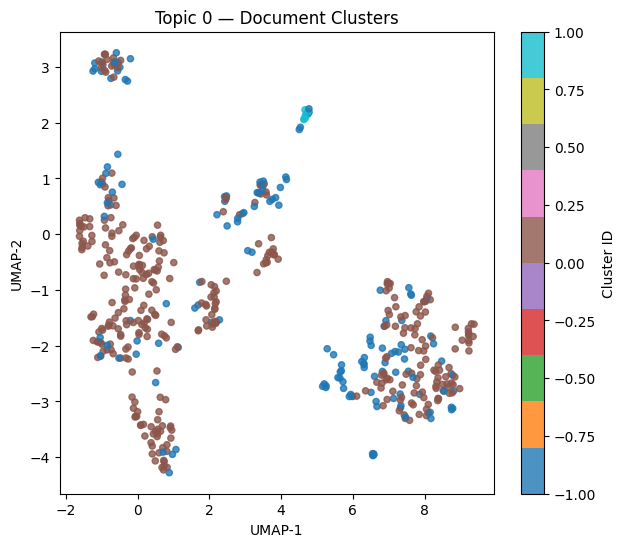

In [22]:
cluster_and_plot_topic(df, topic_id=0)


In [30]:
def cluster_radar_for_topic(
    df: pd.DataFrame,
    topic_id: int,
    text_col: str = "Document",
    min_cluster_size: int = 10,
    max_clusters_to_plot: int = 6,   # keep radar readable
    axes_top_k: int = 12,            # number of radar axes (words)
    ngram_range=(1, 2),              # use (1,2) to allow phrases
    stop_words="english",
    random_state: int = 42,
):
    # ---- 1) Filter topic ----
    sub = df[df["Topic"] == topic_id].copy()
    if sub.empty:
        raise ValueError(f"Topic {topic_id} not found.")
    docs = sub[text_col].fillna("").astype(str).tolist()

    if len(docs) < min_cluster_size:
        raise ValueError(f"Topic {topic_id} has only {len(docs)} docs; increase topic size or lower min_cluster_size.")

    # ---- 2) Embed + cluster docs within topic ----
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    emb = embedder.encode(docs, show_progress_bar=True)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean",
        prediction_data=False
    )
    labels = clusterer.fit_predict(emb)
    sub["cluster"] = labels

    # Keep non-noise clusters
    cl_counts = sub[sub["cluster"] != -1]["cluster"].value_counts()
    if cl_counts.empty:
        raise ValueError(f"Topic {topic_id}: HDBSCAN found no clusters (all noise). Try lowering min_cluster_size.")

    # Choose top clusters by size (readability)
    chosen_clusters = cl_counts.head(max_clusters_to_plot).index.tolist()

    # ---- 3) Build TF-IDF on the topic docs (so axes are comparable) ----
    vectorizer = TfidfVectorizer(
        stop_words=stop_words,
        ngram_range=ngram_range,
        max_features=5000
    )
    X = vectorizer.fit_transform(sub[text_col].fillna("").astype(str))
    vocab = np.array(vectorizer.get_feature_names_out())

    # ---- 4) Pick common radar axes (words) from chosen clusters ----
    # Strategy: take top words per cluster (by mean TF-IDF), union them, then trim to axes_top_k
    candidate_words = []
    cluster_profiles = {}  # cluster -> (words, scores) over full vocab

    for c in chosen_clusters:
        idx = (sub["cluster"].values == c)
        Xc = X[idx]
        mean_tfidf = np.asarray(Xc.mean(axis=0)).ravel()
        cluster_profiles[c] = mean_tfidf

        top_idx = mean_tfidf.argsort()[::-1][:max(axes_top_k, 25)]
        candidate_words.extend(vocab[top_idx].tolist())

    # Deduplicate while keeping rough importance order:
    # Score candidates by max TF-IDF across chosen clusters
    candidate_words = list(dict.fromkeys(candidate_words))
    cand_idx = np.array([np.where(vocab == w)[0][0] for w in candidate_words if w in set(vocab)])
    cand_scores = np.zeros(len(cand_idx))

    # max across clusters
    for i, vi in enumerate(cand_idx):
        cand_scores[i] = max(cluster_profiles[c][vi] for c in chosen_clusters)

    # Select final axes
    best = cand_idx[np.argsort(cand_scores)[::-1][:axes_top_k]]
    axes_words = vocab[best].tolist()

    # ---- 5) Build normalized values per cluster on the same axes ----
    values_by_cluster = {}
    for c in chosen_clusters:
        mean_tfidf = cluster_profiles[c]
        vals = np.array([mean_tfidf[np.where(vocab == w)[0][0]] for w in axes_words], dtype=float)

        # Normalize within cluster so radar shows shape (not size)
        mx = vals.max()
        vals = vals / mx if mx > 0 else vals
        values_by_cluster[c] = vals

    # ---- 6) Radar plot (overlay clusters) ----
    labels_words = axes_words
    angles = np.linspace(0, 2*np.pi, len(labels_words), endpoint=False)
    angles = np.append(angles, angles[0])

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for c in chosen_clusters:
        vals = values_by_cluster[c]
        vals = np.append(vals, vals[0])
        ax.plot(angles, vals, linewidth=2, label=f"Cluster {c} (n={cl_counts[c]})")
        ax.fill(angles, vals, alpha=0.10)

    ax.set_thetagrids(angles[:-1] * 180 / np.pi, labels_words)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Topic {topic_id} — Cluster radar (TF-IDF, normalized)", y=1.10)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10))

    plt.show()

    # Return the dataframe with cluster labels in case you want to save it
    return sub

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

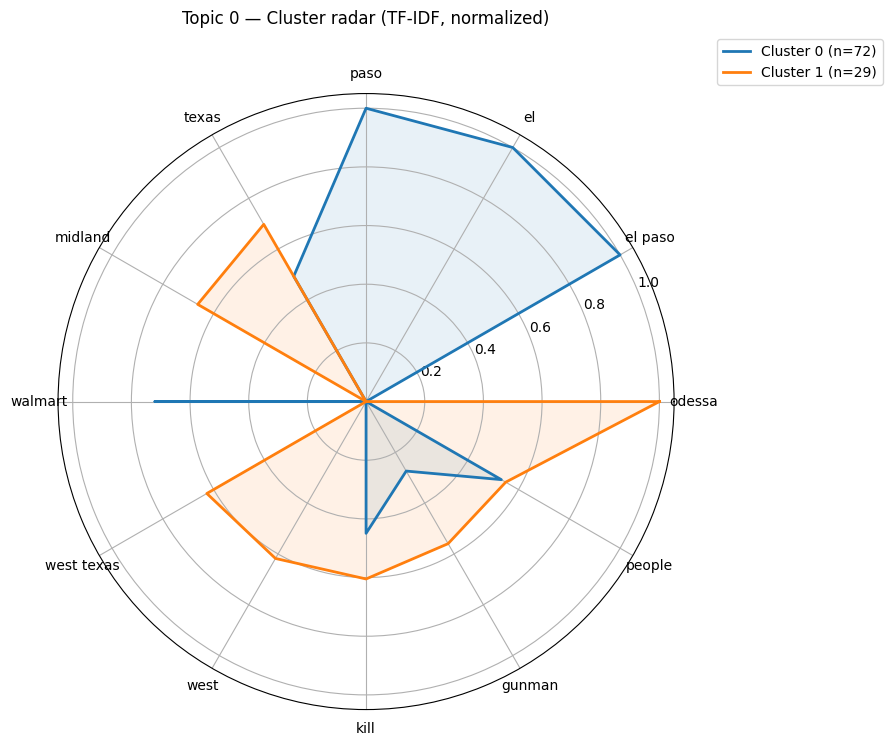

In [32]:
clustered_topic0 = cluster_radar_for_topic(radar_topics, topic_id=0, min_cluster_size=15, axes_top_k=12)